In [1]:
# importing major libaries 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 

# additional libraries 
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading dataset 
df = pd.read_csv('Magicbricks.csv')

In [3]:
# overview 

df.head()

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
0,950.0,2,2.0,Furnished,Karol Bagh,Central Delhi,"DDA MIG Flats Prasad Nagar Phase 2, Prasad Nag...",1.0,Ready_to_move,Resale,Apartment,8761.0,12500000
1,535.0,2,1.0,Furnished,Karol Bagh,Central Delhi,"Dev Nagar, Karol Bagh",1.0,Ready_to_move,New_Property,Apartment,7290.0,3900000
2,1280.0,3,3.0,Furnished,Karol Bagh,Central Delhi,Karol Bagh,2.0,Ready_to_move,Resale,Builder_Floor,14092.0,15000000
3,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000
4,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000


# DAP -- Data Analysis Process

- Problem
- Data wrangling
  - Data Gathering(api,db,warehouse,csv)
  - Data Assessing
  - Data Cleaning
- Exploratory Analysis
  - Statistical Methods
  - Graphs
- Reports
- Dashboards --> Power Bi and Tableau
- Advisories

In [4]:
# data assessing 

df.head()

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
0,950.0,2,2.0,Furnished,Karol Bagh,Central Delhi,"DDA MIG Flats Prasad Nagar Phase 2, Prasad Nag...",1.0,Ready_to_move,Resale,Apartment,8761.0,12500000
1,535.0,2,1.0,Furnished,Karol Bagh,Central Delhi,"Dev Nagar, Karol Bagh",1.0,Ready_to_move,New_Property,Apartment,7290.0,3900000
2,1280.0,3,3.0,Furnished,Karol Bagh,Central Delhi,Karol Bagh,2.0,Ready_to_move,Resale,Builder_Floor,14092.0,15000000
3,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000
4,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000


In [5]:
# columns 

df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Location', 'District',
       'Locality', 'Parking', 'Status', 'Transaction', 'Type', 'Per_Sqft',
       'Price'],
      dtype='object')

### MagicBricks Dataset – Data Card 

**Dataset Name:** MagicBricks Housing Dataset
**Domain:** Real Estate
**Purpose:** Used to analyze housing prices and build models to **predict property price** based on property features.

---

### Columns Description

* **Area** – Size of the property (in square feet).
* **BHK** – Number of Bedrooms, Hall, and Kitchen.
* **Bathroom** – Number of bathrooms in the property.
* **Furnishing** – Furnishing status (Furnished / Semi-Furnished / Unfurnished).
* **Location** – Area where the property is located.
* **District** – District of the property.
* **Locality** – Specific neighborhood within the location.
* **Parking** – Availability of parking space.
* **Status** – Construction status (Ready to Move / Under Construction).
* **Transaction** – Type of transaction (New Property / Resale).
* **Type** – Type of property (Apartment, Builder Floor, Villa, etc.).
* **Per_Sqft** – Price per square foot.
* **Price** – Total price of the property (**Target Variable**).

In [6]:
# manual assessing 
# seeking info 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214 entries, 0 to 1213
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1214 non-null   float64
 1   BHK          1214 non-null   int64  
 2   Bathroom     1212 non-null   float64
 3   Furnishing   1214 non-null   object 
 4   Location     1214 non-null   object 
 5   District     1214 non-null   object 
 6   Locality     1214 non-null   object 
 7   Parking      1182 non-null   float64
 8   Status       1214 non-null   object 
 9   Transaction  1214 non-null   object 
 10  Type         1209 non-null   object 
 11  Per_Sqft     973 non-null    float64
 12  Price        1214 non-null   int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 123.4+ KB


### Dataset Information

* The dataset consists of **1,214 rows and 13 columns**, representing the observations and features used for analysis.
* The dataset contains **null (missing) values**, which may require appropriate data cleaning techniques such as imputation or removal before performing analysis or modeling.
* A **validity issue** is observed where the **Bathroom** and **Parking** columns are stored in **float data type**, even though these values should logically be integers since they represent counts.
* The dataset includes **6 numerical columns** used for quantitative analysis and **7 object-type columns** that represent categorical or textual information.


In [7]:
# messy data vs dirty data 

# Dirty Data Issues

Dirty data refers to data that is **incorrect, incomplete, inconsistent, or unrealistic**, which can affect analysis and machine learning results.

## 1. Validity Issues

Validity problems occur when data **does not follow logical rules or defined formats**.

Examples:

* Duplicate entries such as the same **Patient ID appearing multiple times**
* Incorrect **data types** (e.g., age stored as text instead of numbers)
* **Negative values** where they are not possible (e.g., age = -5)

These issues make the dataset **invalid for analysis** and must be corrected.


## 2. Accuracy Issues

Accuracy issues occur when the value is **technically possible but not logically correct in real life**.

Examples:

* Adult weight recorded as **15 kg**
* Age recorded as **202 years**

Although these values are numbers and not technically wrong in format, they are **not realistic**, which reduces data reliability.

## 3. Completeness Issues

Completeness issues occur when **important data is missing or blank**.

Examples:

* Missing values in columns like **age, address, salary, or patient diagnosis**
* Empty cells in datasets

Incomplete data can lead to **biased analysis or incorrect conclusions**.


## 4. Inconsistency Issues

Inconsistency occurs when the **same information is represented in different formats**.

Examples:

* Name variations: **Ujjwal, Ujjawal**
* Location variations: **NYC, New York City**

These inconsistencies create problems in **grouping, filtering, and analysis**.

In [8]:
# seeking description of the dataset 

df.describe()

,Area,BHK,Bathroom,Parking,Per_Sqft,Price
count,1214.000000,1214.000000,1212.000000,1182.000000,973.000000,1.214000e+03
mean,1451.850751,2.778418,2.523927,1.708122,15574.885920,2.079898e+07
std,1586.472855,0.946811,1.017723,5.717177,21574.389007,2.561308e+07
min,28.000000,1.000000,1.000000,1.000000,1259.000000,1.000000e+06
25%,800.000000,2.000000,2.000000,1.000000,6154.000000,5.600000e+06
50%,1150.000000,3.000000,2.000000,1.000000,10838.000000,1.400000e+07
75%,1620.000000,3.000000,3.000000,2.000000,17647.000000,2.500000e+07
max,24300.000000,10.000000,7.000000,114.000000,183333.000000,2.400000e+08


### Potential Issues in the Dataset

* The **maximum value in the Area column is 24,300**, which appears unusually high compared to typical residential property sizes. This may indicate the presence of **outliers or possible data entry errors** that should be investigated.
* The **Parking column contains a value of 114**, which is highly unrealistic for a residential property. This suggests a **potential data quality issue or incorrect entry** that requires validation or correction before analysis.


In [9]:
# null values 

temp = df.isnull().sum()[df.isnull().sum()>0]
temp

Bathroom      2
Parking      32
Type          5
Per_Sqft    241
dtype: int64

In [10]:
df.isnull().mean()*100

Area            0.000000
BHK             0.000000
Bathroom        0.164745
Furnishing      0.000000
Location        0.000000
District        0.000000
Locality        0.000000
Parking         2.635914
Status          0.000000
Transaction     0.000000
Type            0.411862
Per_Sqft       19.851730
Price           0.000000
dtype: float64

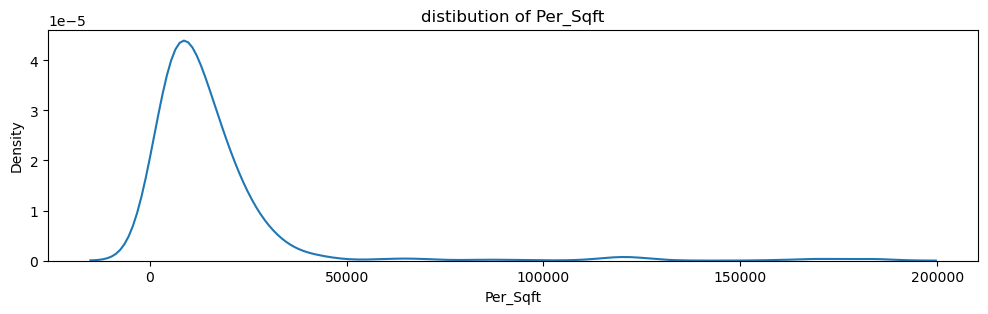

skewness 5.26


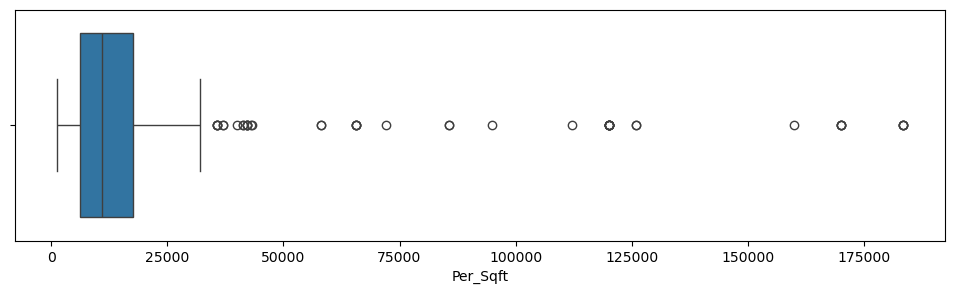

In [11]:
df.Per_Sqft
plt.figure(figsize=(12,3))
sns.kdeplot(data=df,x='Per_Sqft')
plt.title('distibution of Per_Sqft')
plt.show()
print('skewness',df.Per_Sqft.skew().round(2))
plt.figure(figsize=(12,3))
sns.boxplot(data=df,x='Per_Sqft')
plt.show()

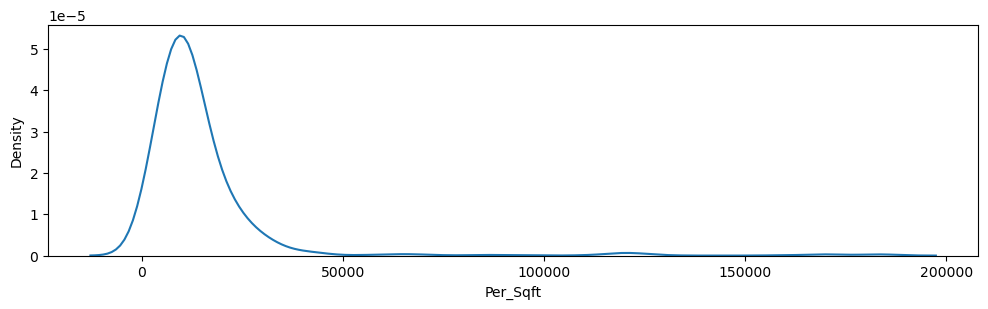

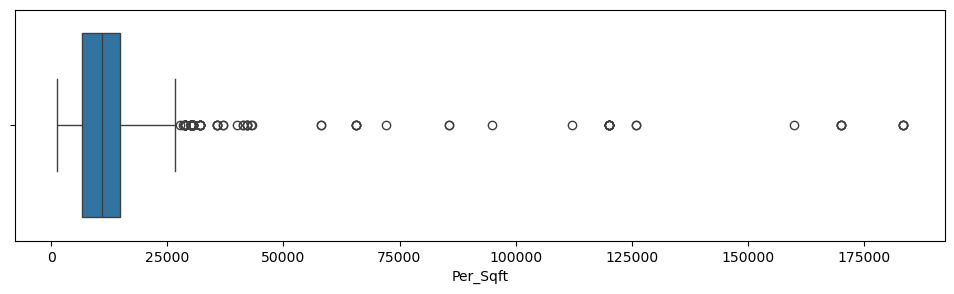

In [12]:
# not an idol way 
plt.figure(figsize=(12,3))
sns.kdeplot(x=df.Per_Sqft.fillna(10838))
plt.show()
plt.figure(figsize=(12,3))
sns.boxplot(x=df.Per_Sqft.fillna(10838))
plt.show()

In [13]:
df

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
0,950.0,2,2.0,Furnished,Karol Bagh,Central Delhi,"DDA MIG Flats Prasad Nagar Phase 2, Prasad Nag...",1.0,Ready_to_move,Resale,Apartment,8761.0,12500000
1,535.0,2,1.0,Furnished,Karol Bagh,Central Delhi,"Dev Nagar, Karol Bagh",1.0,Ready_to_move,New_Property,Apartment,7290.0,3900000
2,1280.0,3,3.0,Furnished,Karol Bagh,Central Delhi,Karol Bagh,2.0,Ready_to_move,Resale,Builder_Floor,14092.0,15000000
3,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000
4,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1209,4688.0,5,4.0,Unfurnished,Patel Nagar,West Delhi,"The Leela Sky Villas, Patel Nagar",1.0,Almost_ready,New_Property,Apartment,28797.0,135000000
1210,3901.0,4,4.0,Unfurnished,Patel Nagar,West Delhi,"The Leela Sky Villas, Patel Nagar",1.0,Almost_ready,New_Property,Apartment,23840.0,93000000
1211,2306.0,3,3.0,Unfurnished,Patel Nagar,West Delhi,"The Leela Sky Villas, Patel Nagar",1.0,Almost_ready,New_Property,Apartment,24718.0,57000000
1212,675.0,2,1.0,Unfurnished,Uttam Nagar,West Delhi,Uttam Nagar,1.0,Ready_to_move,Resale,Builder_Floor,5794.0,2900000


In [14]:
# Area 
# 950.0  ---> 12500000
# 1 --> 12500000/950.0

In [15]:
# temp_l1 = df[df.Per_Sqft.isnull()].index
# df.Per_Sqft.fillna(df.price/df.area).iloc[temp_l1].round(2)
df.Per_Sqft = df.Per_Sqft.fillna(df.Price/df.Area).round(2)

In [16]:
df.isnull().sum()

Area            0
BHK             0
Bathroom        2
Furnishing      0
Location        0
District        0
Locality        0
Parking        32
Status          0
Transaction     0
Type            5
Per_Sqft        0
Price           0
dtype: int64

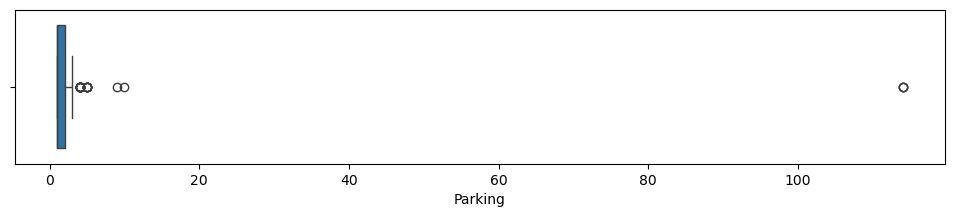

In [17]:
df.Parking.describe()
plt.figure(figsize=(12,2))
sns.boxplot(x=df.Parking)
plt.show()

In [18]:
df[df.Parking>20]
df.Parking = np.where(df.Parking>20,1,df.Parking)

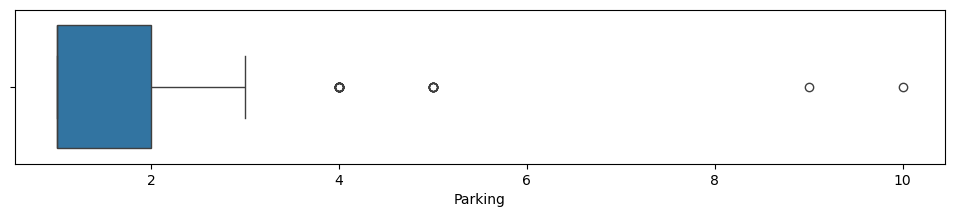

In [19]:
plt.figure(figsize=(12,2))
sns.boxplot(x=df.Parking)
plt.show()

In [20]:
df.Parking.describe()

count    1182.000000
mean        1.421320
std         0.757789
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: Parking, dtype: float64

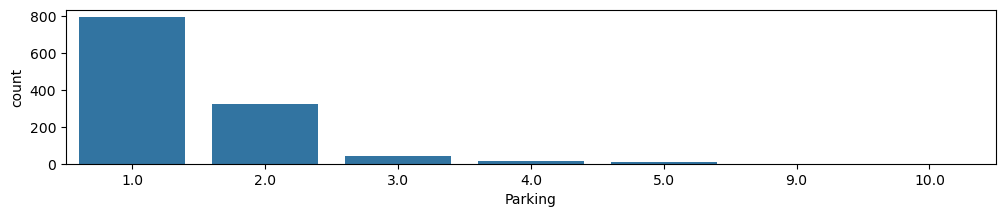

In [21]:
df.Parking.describe()
plt.figure(figsize=(12,2))
sns.countplot(x=df.Parking)
plt.show()

In [22]:
df.Parking.median()
df.Parking.fillna(1,inplace=True)

In [23]:
df.isnull().sum()
# dropna
df.dropna(inplace=True)

In [24]:
df.shape

(1207, 13)

In [25]:
# validity issues

df.dtypes

df.Bathroom = df.Bathroom.astype(int)
df.Parking = df.Parking.astype(int)


In [26]:
df.dtypes

Area           float64
BHK              int64
Bathroom         int64
Furnishing      object
Location        object
District        object
Locality        object
Parking          int64
Status          object
Transaction     object
Type            object
Per_Sqft       float64
Price            int64
dtype: object

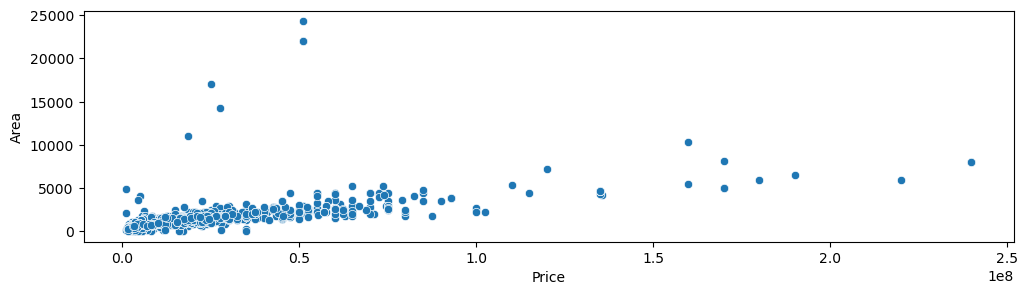

In [27]:
# price and area comparisons

df.Price
df.Area
plt.figure(figsize=(12,3))
sns.scatterplot(data=df,x='Price',y='Area')
plt.show()

In [28]:
df[df.Area>10000]

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
429,22050.0,4,4,Semi-Furnished,Greater Kailash,South Delhi,Greater Kailash 1,2,Almost_ready,New_Property,Builder_Floor,30556.0,51000000
431,22050.0,4,4,Semi-Furnished,Greater Kailash,South Delhi,Greater Kailash 1,2,Almost_ready,New_Property,Builder_Floor,30556.0,51000000
515,10350.0,4,7,Semi-Furnished,Friends Colony,South Delhi,"Maharani Bagh, New Friends Colony",3,Ready_to_move,New_Property,Apartment,15459.0,160000000
603,24300.0,4,5,Semi-Furnished,Saket,South Delhi,Saket,2,Ready_to_move,Resale,Builder_Floor,12500.0,51000000
806,14220.0,3,3,Semi-Furnished,Paschim Vihar,West Delhi,Paschim Vihar Block B4,1,Ready_to_move,New_Property,Builder_Floor,10943.0,27500000
835,17010.0,3,3,Semi-Furnished,Punjabi Bagh,West Delhi,Punjabi Bagh West,2,Ready_to_move,Resale,Builder_Floor,15278.0,25000000
978,11050.0,3,3,Unfurnished,Chittaranjan Park,South Delhi,Chittaranjan Park,1,Ready_to_move,New_Property,Builder_Floor,12916.0,18500000


In [29]:
(22050*30556.0) /51000000

13.210976470588236

In [30]:
df.Area = np.where(df.Area>10000,df.Area/10,df.Area)

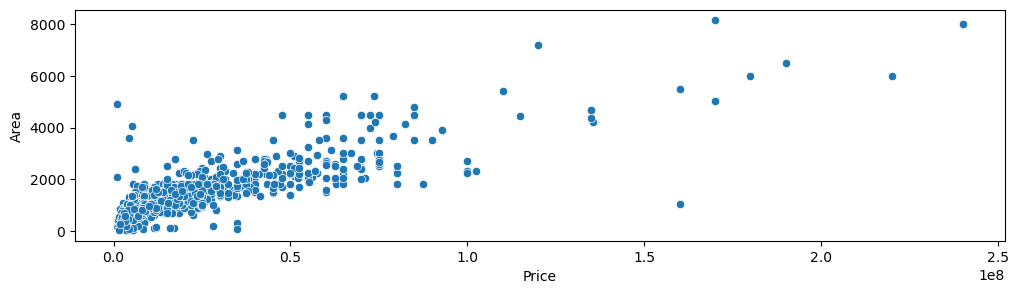

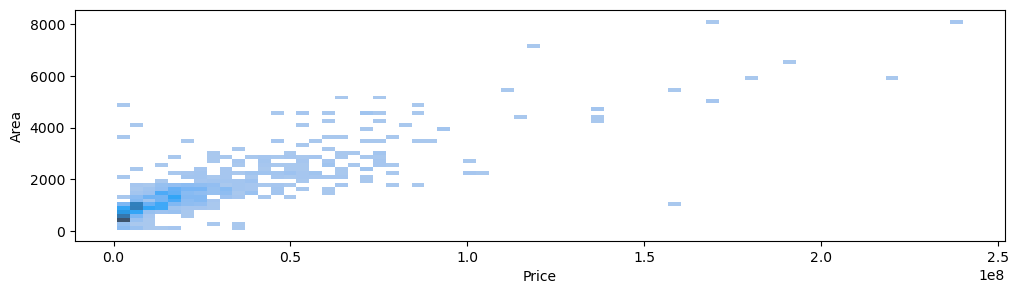

In [31]:
plt.figure(figsize=(12,3))
sns.scatterplot(data=df,x='Price',y='Area')
plt.show()
plt.figure(figsize=(12,3))
sns.histplot(data=df,x='Price',y='Area')
plt.show()

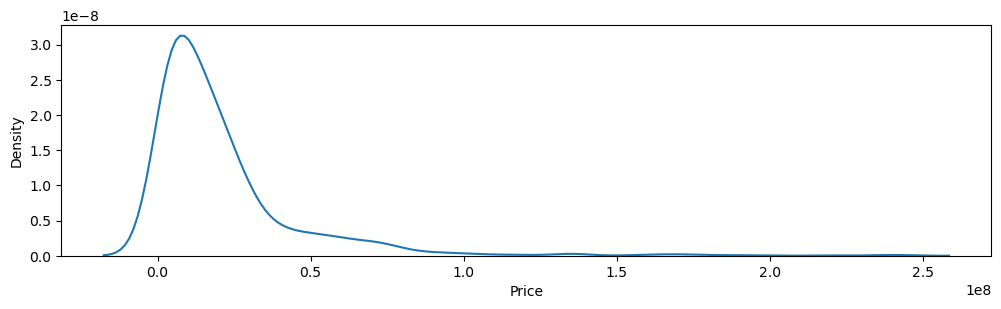

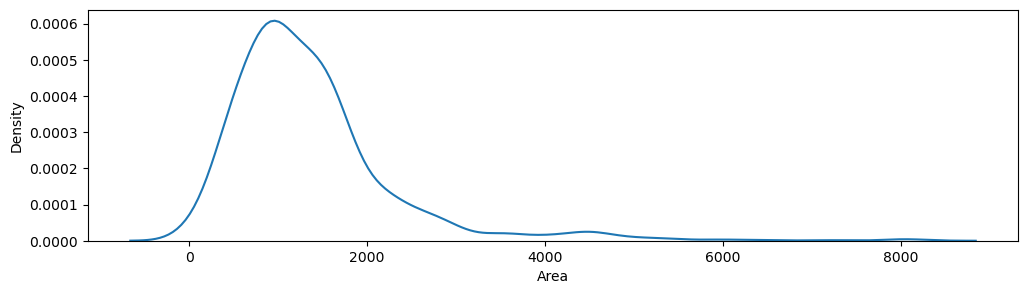

In [32]:
plt.figure(figsize=(12,3))
sns.kdeplot(df.Price)
plt.show()
plt.figure(figsize=(12,3))
sns.kdeplot(df.Area)
plt.show()

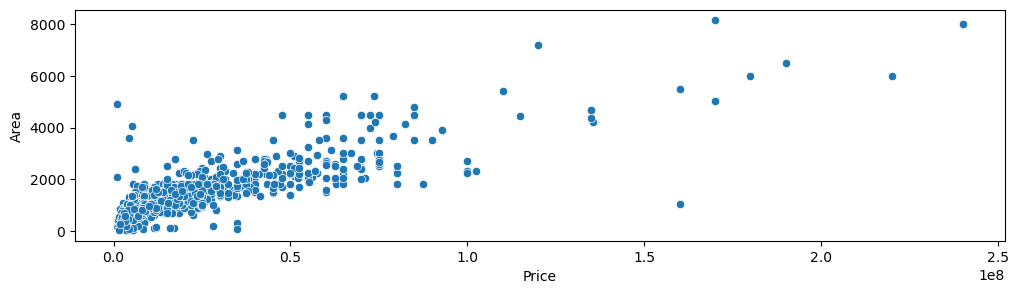

In [33]:
plt.figure(figsize=(12,3))
sns.scatterplot(data=df,x='Price',y='Area')
plt.show()

In [35]:
filtered_df = df[(df.Area > 2000) & (df.Price < 10000000)]
filtered_df

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
37,4050.0000,6,3,Furnished,Budh Vihar,North West Delhi,Budh Vihar Phase 1,1,Ready_to_move,Resale,Builder_Floor,1259.0,5100000
39,2400.0000,6,4,Furnished,Budh Vihar,North West Delhi,Budh Vihar Phase 2,1,Ready_to_move,Resale,Builder_Floor,2500.0,6000000
387,3600.0000,2,2,Semi-Furnished,Chhattarpur,South Delhi,Chhattarpur carpet area 400 sqyrd status Ready...,1,Ready_to_move,New_Property,Builder_Floor,1250.0,4500000
912,2077.4327,1,1,Unfurnished,Narela,North West Delhi,"DDA Flats Pocket 3, Narela",1,Ready_to_move,Resale,Builder_Floor,5051.0,1000000
918,4900.0000,1,1,Unfurnished,Narela,North West Delhi,"DDA Lig Flats, Narela",1,Ready_to_move,New_Property,Apartment,5051.0,1000000


In [36]:
# row 912 and 918 have problem

In [37]:
df.Area.describe()

count    1207.000000
mean     1362.493631
std       953.446919
min        28.000000
25%       800.000000
50%      1150.000000
75%      1620.000000
max      8150.000000
Name: Area, dtype: float64

In [38]:
df[df.Area<300].shape

df= df[df.Area>300]
df

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
0,950.0,2,2,Furnished,Karol Bagh,Central Delhi,"DDA MIG Flats Prasad Nagar Phase 2, Prasad Nag...",1,Ready_to_move,Resale,Apartment,8761.0,12500000
1,535.0,2,1,Furnished,Karol Bagh,Central Delhi,"Dev Nagar, Karol Bagh",1,Ready_to_move,New_Property,Apartment,7290.0,3900000
2,1280.0,3,3,Furnished,Karol Bagh,Central Delhi,Karol Bagh,2,Ready_to_move,Resale,Builder_Floor,14092.0,15000000
3,1135.0,3,3,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2,Almost_ready,Resale,Apartment,22222.0,25000000
4,1135.0,3,3,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2,Almost_ready,Resale,Apartment,22222.0,25000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1209,4688.0,5,4,Unfurnished,Patel Nagar,West Delhi,"The Leela Sky Villas, Patel Nagar",1,Almost_ready,New_Property,Apartment,28797.0,135000000
1210,3901.0,4,4,Unfurnished,Patel Nagar,West Delhi,"The Leela Sky Villas, Patel Nagar",1,Almost_ready,New_Property,Apartment,23840.0,93000000
1211,2306.0,3,3,Unfurnished,Patel Nagar,West Delhi,"The Leela Sky Villas, Patel Nagar",1,Almost_ready,New_Property,Apartment,24718.0,57000000
1212,675.0,2,1,Unfurnished,Uttam Nagar,West Delhi,Uttam Nagar,1,Ready_to_move,Resale,Builder_Floor,5794.0,2900000


In [42]:
df.describe()

df[df.Per_Sqft>=183333]

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
507,2700.0,4,4,Semi-Furnished,Lajpat Nagar,South Delhi,Lajpat Nagar 3,2,Ready_to_move,Resale,Builder_Floor,183333.0,55000000
508,1400.0,3,3,Semi-Furnished,Lajpat Nagar,South Delhi,Lajpat Nagar 3,1,Ready_to_move,New_Property,Builder_Floor,183333.0,32500000
1028,1400.0,3,3,Unfurnished,Lajpat Nagar,South Delhi,Lajpat Nagar 3,1,Ready_to_move,Resale,Builder_Floor,183333.0,24500000
1029,1800.0,3,3,Unfurnished,Lajpat Nagar,South Delhi,Lajpat Nagar 3,1,Ready_to_move,Resale,Apartment,183333.0,24500000


In [43]:
df.shape

(1177, 13)

In [44]:
df.District.value_counts()

District
South Delhi          454
West Delhi           144
East Delhi           129
North West Delhi     112
South West Delhi      93
South West Delhi      87
Shahdara              68
South East Delhi      58
Central Delhi         32
Name: count, dtype: int64

In [46]:
df.District.unique()      # Incosistency

array(['Central Delhi', 'East Delhi', 'North West Delhi', 'Shahdara',
       'South Delhi', 'South East Delhi', 'South West Delhi',
       'South West Delhi ', 'West Delhi'], dtype=object)

In [48]:
df.District.unique()
len(df.District.unique())

9

In [49]:
df.District = df.District.str.strip()
len(df.District.unique())

8

In [50]:
# clean data 

df.to_csv('magic_bricks_clean.csv',index=False)